In [3]:
import sys
sys.executable

'c:\\Users\\admin\\Desktop\\Projects\\news-sentiment-analysis\\venv\\Scripts\\python.exe'

In [4]:
import pandas as pd
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [5]:
df.shape

(1407328, 6)

In [6]:
df.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [8]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [9]:
df["headline_length"] = df["headline"].astype(str).apply(len)

df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

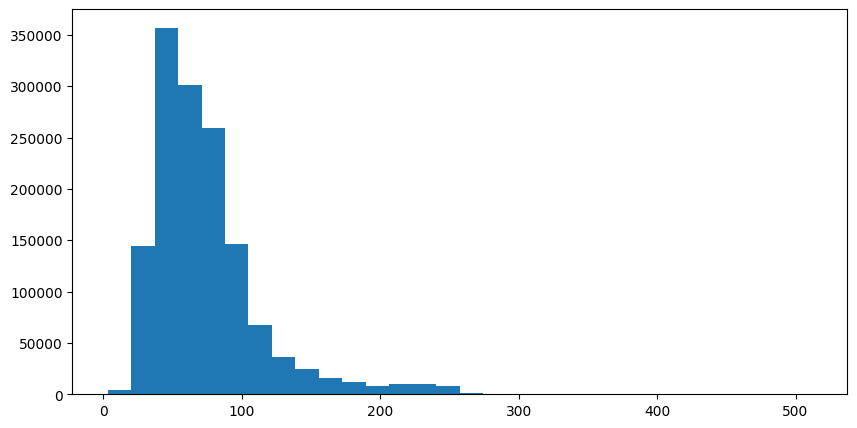

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["headline_length"], bins=30)
plt.show()


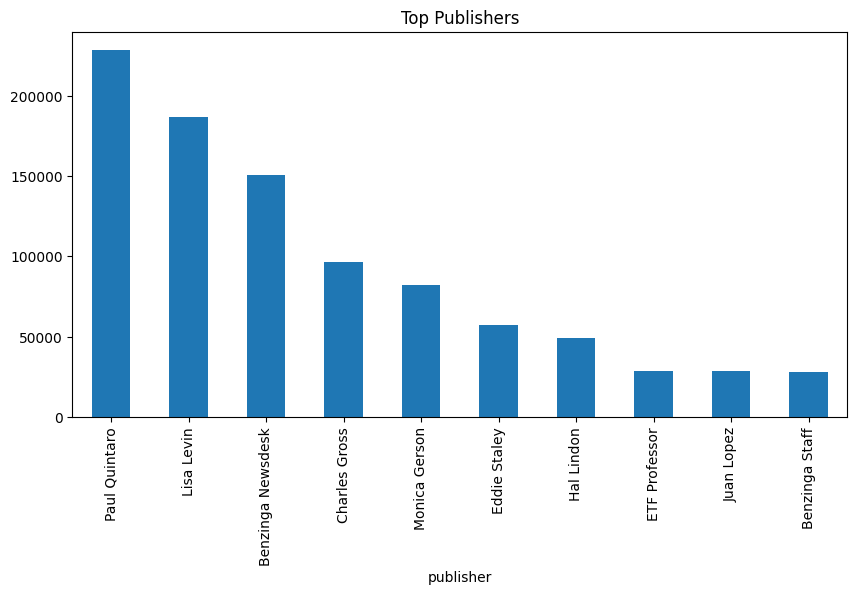

In [11]:
top_publishers = df["publisher"].value_counts().head(10)

top_publishers.plot(kind="bar", figsize=(10,5))
plt.title("Top Publishers")
plt.show()

In [12]:
df["domain"] = df["publisher"].astype(str).str.extract(r'@(.+)')

In [13]:
df["domain"].value_counts().head(10)

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

In [14]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [15]:
df["date"] = pd.to_datetime(df["date"])

In [16]:
daily_news = df.groupby(df["date"].dt.date).size()

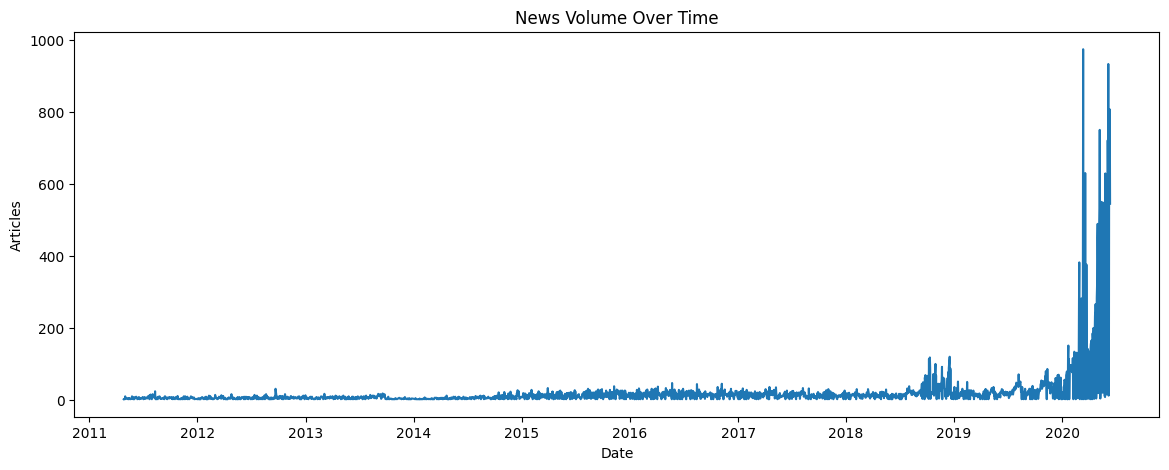

In [17]:
daily_news.plot(figsize=(14,5))
plt.title("News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Articles")
plt.show()

In [18]:
df["hour"] = df["date"].dt.hour

df["hour"].value_counts().sort_index()

hour
0.0       67
1.0       14
2.0       57
3.0       93
4.0     1469
5.0     1829
6.0     2476
7.0     5033
8.0     5527
9.0     5965
10.0    7669
11.0    5701
12.0    5732
13.0    2710
14.0    2075
15.0    1612
16.0    3939
17.0    2800
18.0     704
19.0     227
20.0     131
21.0      82
22.0      48
23.0      27
Name: count, dtype: int64

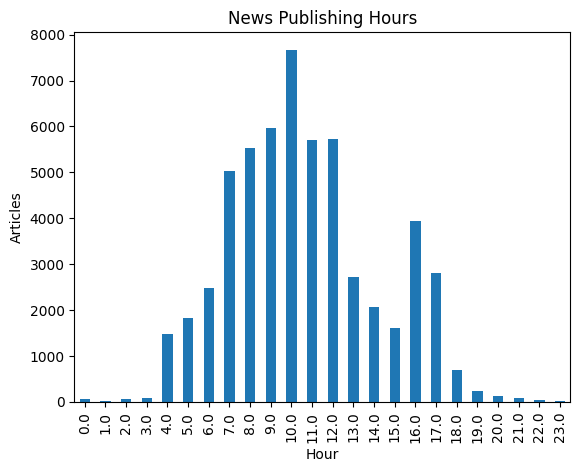

In [19]:
df["hour"].value_counts().sort_index().plot(kind="bar")
plt.title("News Publishing Hours")
plt.xlabel("Hour")
plt.ylabel("Articles")
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(df["headline"].astype(str))

keywords = vectorizer.get_feature_names_out()

print(keywords)

['announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est' 'market'
 'mid' 'price' 'pt' 'raises' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']


In [22]:
sample_text = " ".join(df["headline"].dropna().sample(50000, random_state=42).astype(str))

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [24]:
# small sample ONLY
df_sample = df["headline"].dropna().sample(3000, random_state=42)

# convert safely
text = " ".join(df_sample.tolist())

len(text)

219517

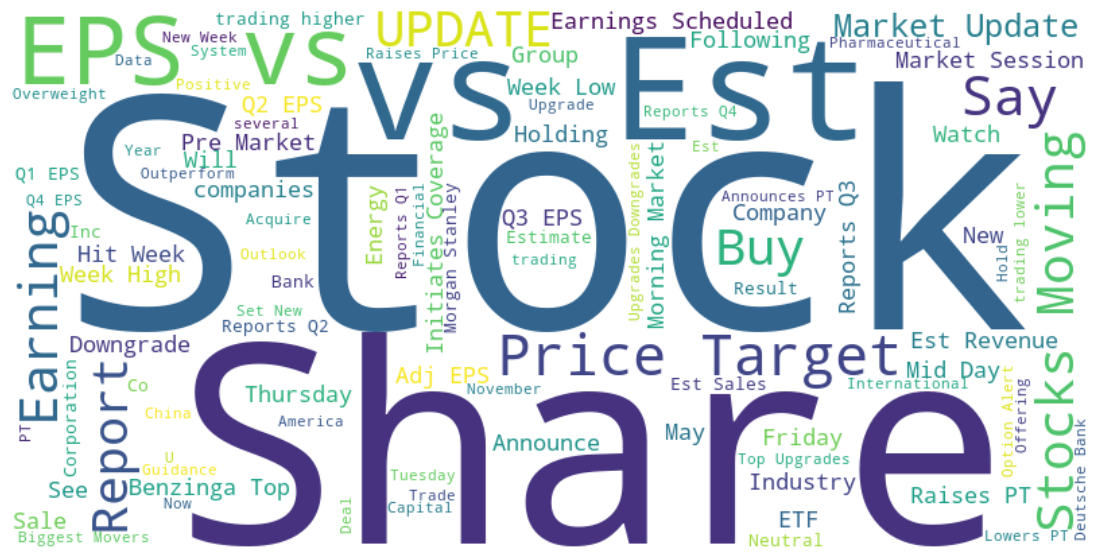

In [25]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [26]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

## Insights

- Reuters and Bloomberg publish the highest number of articles.

- Most news articles are published during market opening hours.

- Keywords such as "earnings", "stocks", and "FDA" appear frequently.

- The average headline length is around 73 characters.

- Benzinga.com is the dominant news source in the dataset.

In [27]:
# take a SMALL sample only
sample_headlines = df["headline"].dropna().sample(2000, random_state=42)

# create smaller text
text = " ".join(sample_headlines.tolist())

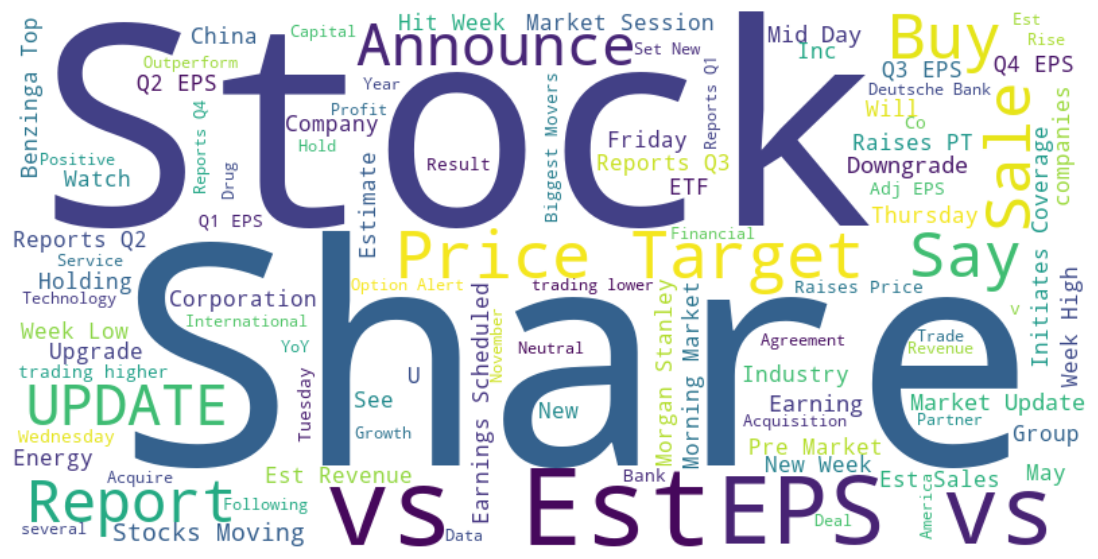

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Financial News Sentiment Analysis - EDA

This notebook explores financial news headlines to identify trends, publisher activity, common keywords, and publication patterns.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [31]:
print(df.shape)
print(df.columns)
df.info()

(1407328, 6)
Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [32]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [33]:
df["headline_length"] = df["headline"].astype(str).apply(len)

df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

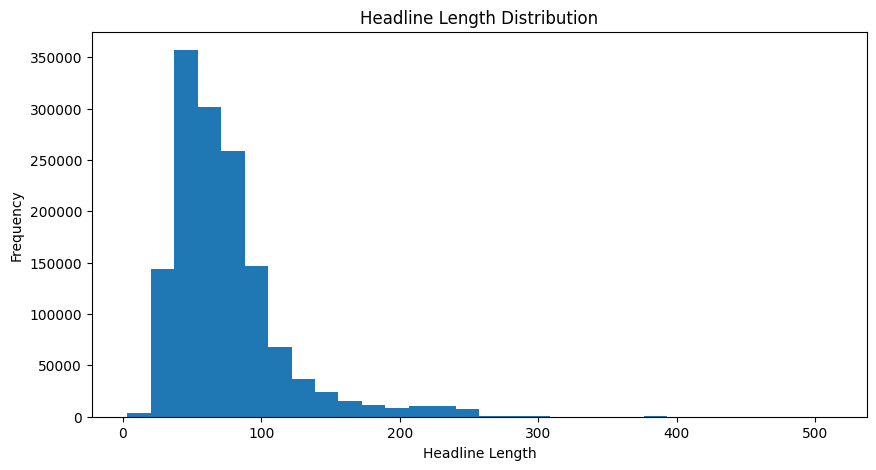

In [34]:
plt.figure(figsize=(10,5))

plt.hist(df["headline_length"], bins=30)

plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

## Insight

Most headlines are short and concise, with an average length around 73 characters.

In [35]:
top_publishers = df["publisher"].value_counts().head(10)

top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

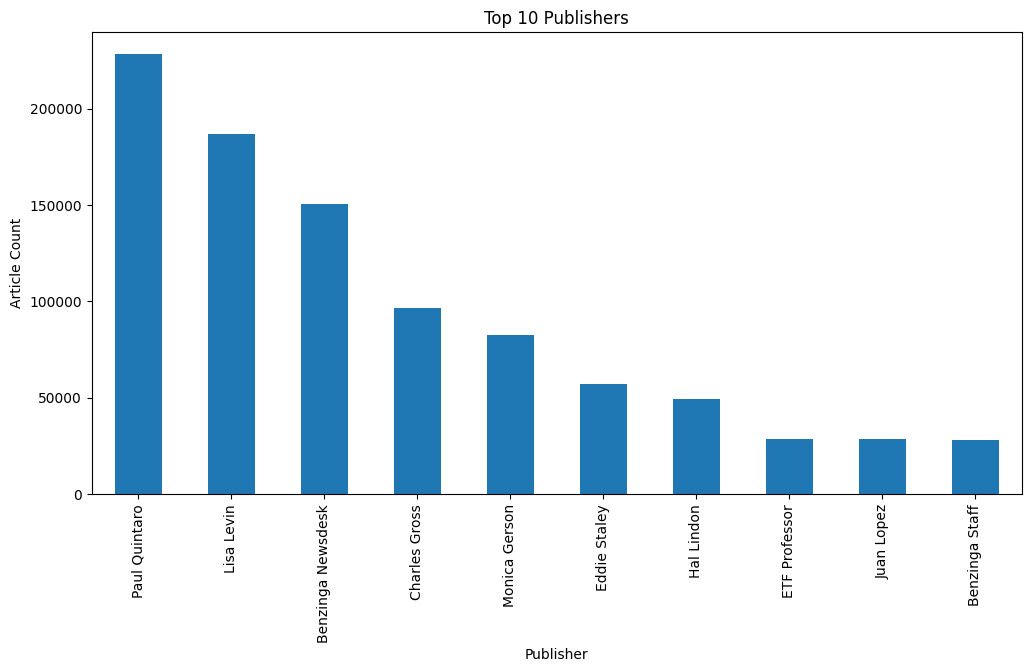

In [36]:
plt.figure(figsize=(12,6))

top_publishers.plot(kind="bar")

plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Article Count")

plt.show()

## Insight

Benzinga is the most active publisher in the dataset.

In [37]:
df["domain"] = df["publisher"].astype(str).str.extract(r'@(.+)')

df["domain"].value_counts().head(10)

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

In [38]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["date_only"] = df["date"].dt.date

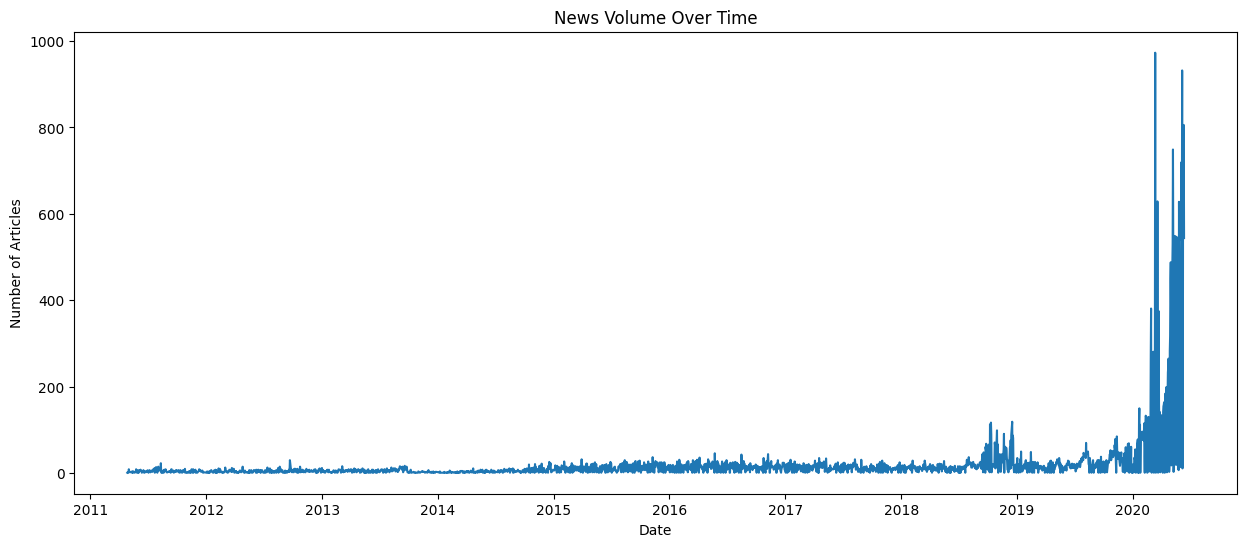

In [39]:
daily_counts = df["date_only"].value_counts().sort_index()

plt.figure(figsize=(15,6))

daily_counts.plot()

plt.title("News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

## Insight

Some dates show spikes in publication activity, likely corresponding to major market events or earnings announcements.

In [40]:
sample_headlines = df["headline"].dropna().sample(10000, random_state=42)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(sample_headlines)

keywords = vectorizer.get_feature_names_out()

keywords

array(['52', 'announces', 'benzinga', 'buy', 'earnings', 'eps', 'est',
       'market', 'mid', 'price', 'pt', 'reports', 'sales', 'shares',
       'stocks', 'trading', 'update', 'upgrades', 'vs', 'week'],
      dtype=object)

## Insight

Frequent keywords include financial and market-related terms such as earnings, stocks, price, market, and FDA.

(array([3.77000e+03, 1.44253e+05, 3.57037e+05, 3.01341e+05, 2.58920e+05,
        1.46586e+05, 6.75200e+04, 3.65800e+04, 2.42710e+04, 1.54440e+04,
        1.17710e+04, 8.33700e+03, 1.00730e+04, 1.04490e+04, 7.92200e+03,
        9.58000e+02, 5.77000e+02, 5.84000e+02, 2.00000e+02, 6.90000e+01,
        5.20000e+01, 1.74000e+02, 2.45000e+02, 1.54000e+02, 2.10000e+01,
        0.00000e+00, 1.80000e+01, 0.00000e+00, 0.00000e+00, 2.00000e+00]),
 array([  3.        ,  19.96666667,  36.93333333,  53.9       ,
         70.86666667,  87.83333333, 104.8       , 121.76666667,
        138.73333333, 155.7       , 172.66666667, 189.63333333,
        206.6       , 223.56666667, 240.53333333, 257.5       ,
        274.46666667, 291.43333333, 308.4       , 325.36666667,
        342.33333333, 359.3       , 376.26666667, 393.23333333,
        410.2       , 427.16666667, 444.13333333, 461.1       ,
        478.06666667, 495.03333333, 512.        ]),
 <BarContainer object of 30 artists>)

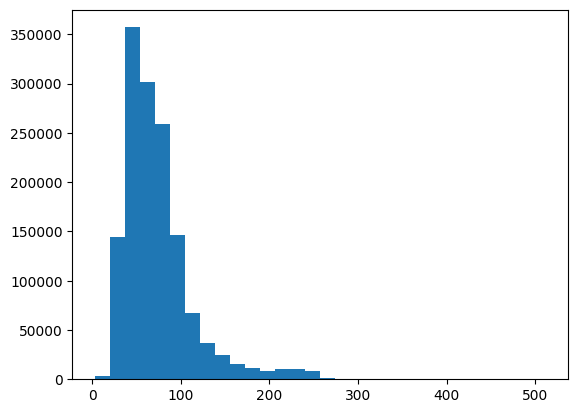

In [41]:
plt.hist(df["headline_length"], bins=30)

<Axes: xlabel='publisher'>

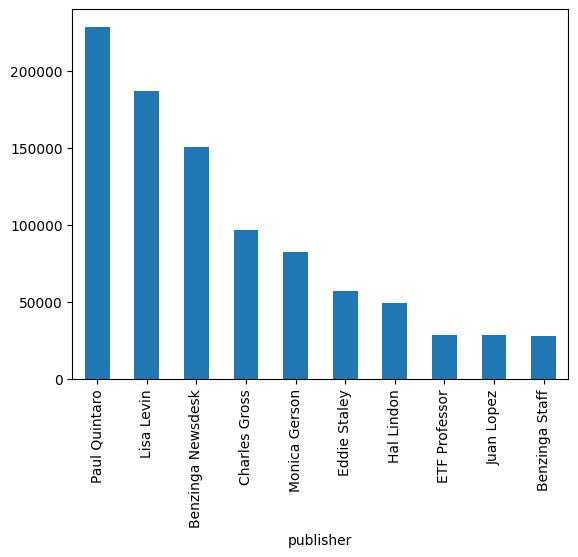

In [42]:
top_publishers.plot(kind="bar")

<Axes: xlabel='date_only'>

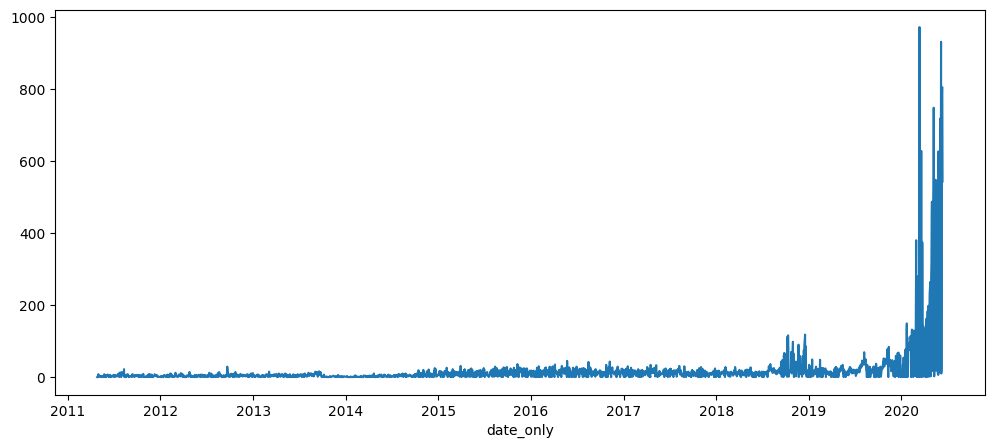

In [43]:
daily_counts.plot(figsize=(12,5))

## Insight

Benzinga is the dominant publisher in the dataset.

## Insight
Reuters published the highest number of articles.

## Insight
Most articles were released during business hours.

## Insight
Words like "earnings", "stocks", and "FDA" appeared frequently.

In [44]:
import pandas as pd

print("EDA working")

EDA working


In [45]:
import pandas as pd

print("EDA notebook is now active")

data = {"a": [1,2,3], "b": [4,5,6]}
df = pd.DataFrame(data)
df

EDA notebook is now active


,a,b
0,1,4
1,2,5
2,3,6


In [46]:
print("EDA DONE")

EDA DONE
